# Práctica 11 — Clustering · RESUELTO
## ¿Quiénes son nuestros usuarios? (PedidosYa Growth)

Resolución de referencia para verificar en casa. Cada sección dice **qué había que buscar, por qué, y qué se encontraba**. Los gráficos son interactivos: pasá el mouse, hacé zoom, rotá los 3D, apretá ▶ en la animación.

> *Material del profesor. Es UNA resolución posible; se evalúa la justificación, no que el código sea idéntico.*

In [1]:
import pandas as pd, numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram

W = 920  # ancho fijo: rinde igual en Colab y VSCode
pio.templates.default = 'plotly_white'
COL = {'full-canasta':'#4C72B0','antojo':'#DD8452','dormidos':'#C44E52','gourmet':'#55A868'}
def fijar(fig, h):
    fig.update_layout(width=W, height=h, autosize=False, margin=dict(t=60,b=40,l=60,r=30))
    return fig
print('setup ok')

setup ok


## La metodología: CRISP-DM

Todo el TP sigue el ciclo estándar de un proyecto de datos. Cada sección de la consigna es una fase; el ciclo es iterativo (si la evaluación no cierra, se vuelve).

In [2]:
fases=['1 · Negocio','2 · Datos','3 · Preparación','4 · Modelado','5 · Evaluación','6 · Despliegue']
mapa=['¿Qué decisión hay que tomar?','¿Puedo confiar en los datos?','Limpiar y escalar','K-Means: ¿cuántos grupos?','Caracterizar y decidir','La recomendación a Growth']
ang=np.linspace(90,90-360,len(fases),endpoint=False)*np.pi/180
x,y=np.cos(ang),np.sin(ang)
fig=go.Figure()
for i in range(len(fases)):
    j=(i+1)%len(fases)
    fig.add_annotation(x=x[j]*0.8,y=y[j]*0.8,ax=x[i]*0.8,ay=y[i]*0.8,xref='x',yref='y',axref='x',ayref='y',showarrow=True,arrowhead=3,arrowsize=1.5,arrowwidth=2,arrowcolor='#94a3b8')
fig.add_trace(go.Scatter(x=x,y=y,mode='markers+text',text=fases,textposition='middle center',
    marker=dict(size=92,color=['#4C72B0','#4C72B0','#4C72B0','#C44E52','#55A868','#94a3b8']),
    textfont=dict(color='white',size=11),hovertext=mapa,hoverinfo='text'))
fig.add_annotation(x=0,y=0,text='<b>CRISP-DM</b>',showarrow=False,font=dict(size=18,color='#1f2d3d'))
fig.update_layout(title='El ciclo del proyecto (pasá el mouse por cada fase)',showlegend=False,
    xaxis=dict(visible=False,range=[-1.45,1.45]),yaxis=dict(visible=False,range=[-1.4,1.4],scaleanchor='x'))
fijar(fig,520); fig.show()

| Fase CRISP-DM | Sección del TP | Qué se decide |
|---|---|---|
| Business Understanding | 1. El negocio | a qué pregunta respondemos |
| Data Understanding | 2. Los datos | si podemos confiar en la base |
| Data Preparation | 3. Preparación | qué es error y qué es señal |
| Modeling | 4. K-Means | cuántos grupos hay |
| Evaluation | 5. Evaluación | quién es cada grupo y qué hacemos |
| Deployment | (la recomendación) | a quién va la campaña |

## 1 · Negocio — *Business Understanding*

**Qué buscar:** la decisión concreta (hay plata para *una* campaña dirigida, ¿a quién?).  
**Por qué:** sin la pregunta de negocio, el clustering es un ejercicio sin destino.  
**La respuesta:** es **no supervisado** — no hay etiqueta de 'segmento' para predecir; buscamos estructura. (`respuesta_ultima_campania` es historia, no un target.)

In [3]:
pasos=['Tenemos<br>UNA campaña','¿A quién<br>se la mandamos?','Buscar grupos por<br>comportamiento','Sin etiqueta previa →<br><b>NO supervisado</b>']
bw, gap = 2.4, 0.7
fig=go.Figure()
for i,p in enumerate(pasos):
    x0=i*(bw+gap)
    fig.add_shape(type='rect',x0=x0,x1=x0+bw,y0=0,y1=1,line=dict(color='#4C72B0',width=2),fillcolor='#eaf0f7')
    fig.add_annotation(x=x0+bw/2,y=0.5,text=p,showarrow=False,font=dict(size=12))
    if i<len(pasos)-1: fig.add_annotation(x=x0+bw+gap,y=0.5,ax=x0+bw,ay=0.5,xref='x',yref='y',axref='x',ayref='y',showarrow=True,arrowhead=3,arrowwidth=2,arrowcolor='#4C72B0')
tot=len(pasos)*(bw+gap)-gap
fig.update_layout(xaxis=dict(visible=False,range=[-0.3,tot+0.3]),yaxis=dict(visible=False,range=[-0.2,1.2]),title='El problema, en una línea')
fijar(fig,200); fig.show()

## 2 · Datos — *Data Understanding*

**Qué buscar:** ¿se puede confiar en lo que nos dieron?  
**Por qué:** si entrenás con basura, los grupos salen de la basura.  
**Qué encontramos:** el `describe()` canta tres anomalías + duplicados + faltantes.

In [4]:
df=pd.read_csv('usuarios_pedidosya.csv')
gastos=['gasto_restaurantes','gasto_mercados','gasto_bebidas','gasto_farmacia','gasto_kioscos','gasto_premium']
tr=pd.DataFrame({'Anomalía':['Edad imposible','Gasto negativo','Ingreso atípico','Duplicados','Ingresos faltantes'],
  'Evidencia':['anio_nacimiento mín. = 1893 (133 años)','gasto_bebidas mín. = -22.000','ingreso máx. ≈ $16,7M','15 usuario_id repetidos','24 nulos en ingreso_estimado'],
  'Veredicto':['error de carga','error (reversa)','señal (heavy user)','error','falta el dato']})
fig=go.Figure(data=[go.Table(columnwidth=[1,2.2,1.2],
  header=dict(values=['<b>'+c+'</b>' for c in tr.columns],fill_color='#4C72B0',font=dict(color='white',size=12),align='left',height=30),
  cells=dict(values=[tr[c] for c in tr.columns],fill_color=[['#fdecea','#fdecea','#e8f5e9','#fdecea','#fff8e1']],align='left',height=30,font=dict(size=12)))])
fig.update_layout(title='Lo que canta el describe(): error vs. señal'); fijar(fig,300); fig.show()

**El hallazgo clave del EDA:** los *días desde el último pedido* no son una montaña, son **dos** — hay activos y hay quienes se están yendo. Esa segunda joroba es la que después separa a los dormidos.

In [5]:
gt=df[gastos].sum(axis=1)
fig=make_subplots(rows=1,cols=2,subplot_titles=('Días desde el último pedido (¡bimodal!)','Ingreso vs gasto (asoma el outlier de $16,7M)'))
fig.add_trace(go.Histogram(x=df['dias_desde_ultimo_pedido'],nbinsx=40,marker_color='#4C72B0'),row=1,col=1)
fig.add_trace(go.Scatter(x=df['ingreso_estimado'],y=gt,mode='markers',marker=dict(size=4,opacity=0.35,color='#4C72B0'),
    hovertemplate='ingreso %{x:$,.0f}<br>gasto %{y:$,.0f}<extra></extra>'),row=1,col=2)
fig.update_xaxes(title_text='días',row=1,col=1); fig.update_yaxes(title_text='usuarios',row=1,col=1)
fig.update_xaxes(title_text='ingreso (ARS/mes)',row=1,col=2); fig.update_yaxes(title_text='gasto 2 años',row=1,col=2)
fig.update_layout(showlegend=False,title=''); fijar(fig,400); fig.show()

## 3 · Preparación — *Data Preparation*

**Qué buscar:** separar error de señal y dejar la base lista.  
**Por qué:** no todo lo raro se borra — los heavy users son raros pero **son justo lo que Growth quiere entender**.  
**Qué hubiera salido mal:** borrar a los heavy users, imputar con la **media** (la arrastra el outlier), o no escalar.

In [6]:
d=df.drop_duplicates(subset='usuario_id').copy()
d['edad']=2026-d['anio_nacimiento']; d=d[d['edad']<=100]
d=d[(d[gastos]>=0).all(axis=1)]
d['ingreso_estimado']=d['ingreso_estimado'].fillna(d['ingreso_estimado'].median())
d['gasto_total']=d[gastos].sum(axis=1)
features=gastos+['ingreso_estimado','dias_desde_ultimo_pedido']
X=StandardScaler().fit_transform(d[features])
print(f'De {len(df)} filas crudas -> {len(d)} limpias. Matriz para clustering: {X.shape}')

De 2255 filas crudas -> 2234 limpias. Matriz para clustering: (2234, 8)


**Por qué escalar (mostrado):** antes, ingreso y gasto viven en millones y aplastan todo; después, todas las variables hablan en la misma escala.

In [7]:
ant=d[features].std().sort_values(); desp=pd.Series(X.std(axis=0),index=features)[ant.index]
fig=make_subplots(rows=1,cols=2,subplot_titles=('Desvío ANTES de escalar (escala log)','Desvío DESPUÉS (todas ≈ 1)'))
fig.add_trace(go.Bar(y=ant.index,x=ant.values,orientation='h',marker_color='#C44E52'),row=1,col=1)
fig.add_trace(go.Bar(y=desp.index,x=desp.values,orientation='h',marker_color='#55A868'),row=1,col=2)
fig.update_xaxes(type='log',row=1,col=1); fig.update_layout(showlegend=False,title=''); fijar(fig,380); fig.show()

## 4 · Modelado — *K-Means*

**Qué buscar:** cuántos grupos hay, **con evidencia**.  
**Por qué:** el algoritmo no elige K; vos sí.  
**El nudo del TP:** el silhouette es **máximo en k=2** (verdadero pero inútil: solo gasta-mucho/gasta-poco). El codo se aplana tras **k=4**. Desempata el **negocio**.

In [8]:
ks=list(range(2,9)); inercias=[]; siluetas=[]
for k in ks:
    km=KMeans(n_clusters=k,random_state=42,n_init=10).fit(X)
    inercias.append(km.inertia_); siluetas.append(silhouette_score(X,km.labels_))
fig=make_subplots(rows=1,cols=2,subplot_titles=('Método del codo (se aplana en k=4)','Silhouette (máximo en k=2, ¡ojo!)'))
fig.add_trace(go.Scatter(x=ks,y=inercias,mode='lines+markers',line=dict(color='#4C72B0')),row=1,col=1)
fig.add_trace(go.Scatter(x=[4],y=[inercias[2]],mode='markers',marker=dict(size=18,color='#C44E52',symbol='circle-open',line=dict(width=3))),row=1,col=1)
fig.add_trace(go.Scatter(x=ks,y=siluetas,mode='lines+markers',line=dict(color='#4C72B0')),row=1,col=2)
fig.add_trace(go.Scatter(x=[2],y=[siluetas[0]],mode='markers',marker=dict(size=18,color='#DD8452',symbol='circle-open',line=dict(width=3))),row=1,col=2)
fig.update_layout(showlegend=False,title=''); fijar(fig,380); fig.show()

**El algoritmo, en movimiento.** Apretá ▶ para ver cómo K-Means parte la base con distinto K. En k=2 solo hay 'gasta mucho / gasta poco'; recién en **k=4** aparecen los matices accionables.

In [9]:
fr=[]
for k in [2,3,4,5,6]:
    lab=KMeans(n_clusters=k,random_state=42,n_init=10).fit_predict(X)
    t=d[['gasto_total','dias_desde_ultimo_pedido']].copy(); t['K']=k; t['grupo']=lab.astype(str)
    fr.append(t)
anim=pd.concat(fr)
fig=px.scatter(anim,x='dias_desde_ultimo_pedido',y='gasto_total',color='grupo',animation_frame='K',
    range_x=[-3,105],range_y=[-50000,anim['gasto_total'].max()*1.05],opacity=0.55,
    color_discrete_sequence=px.colors.qualitative.Set2,
    labels={'dias_desde_ultimo_pedido':'días sin pedir','gasto_total':'gasto 2 años'},title='K-Means para distinto K (▶ para animar)')
fig.update_traces(marker=dict(size=5))
fig.layout.sliders[0].currentvalue.prefix='K = '
fijar(fig,500); fig.show()

## 5 · Evaluación — ponerle cara a los grupos

**Qué buscar:** quién es cada grupo y un nombre que se entienda solo.  
**Por qué:** un cluster sin nombre no le sirve a Growth.  
**Qué encontramos:** cuatro perfiles. El que importa son **los dormidos** — bajo gasto y ~78 días sin pedir.

In [10]:
d['cluster']=KMeans(n_clusters=4,random_state=42,n_init=10).fit_predict(X)
nombres={0:'full-canasta',1:'antojo',2:'dormidos',3:'gourmet'}
d['segmento']=d['cluster'].map(nombres)
perfil=d.groupby('segmento')[features].mean(); pn=(perfil-perfil.mean())/perfil.std()
fig=px.imshow(pn,text_auto='.1f',color_continuous_scale='RdBu_r',zmin=-2,zmax=2,aspect='auto',
    title='Perfil de cada segmento (desvíos respecto del promedio general)')
fijar(fig,360); fig.show()

**Coordenadas paralelas:** cada línea es un segmento; seguí cómo se separa en cada variable. Los dormidos (rojo) se despegan en *días sin pedir*.

In [11]:
pp=d.groupby('segmento')[features].mean().reset_index()
pp['c']=pp['segmento'].map({'full-canasta':0,'antojo':1,'dormidos':2,'gourmet':3})
fig=px.parallel_coordinates(pp,dimensions=features,color='c',
    color_continuous_scale=[[0,'#4C72B0'],[0.33,'#DD8452'],[0.66,'#C44E52'],[1,'#55A868']],
    labels={f:f.replace('gasto_','g.').replace('_',' ') for f in features},title='Perfil de los 4 segmentos (coordenadas paralelas)')
fijar(fig,440); fig.update_layout(coloraxis_showscale=False, margin=dict(t=100,b=40,l=90,r=80)); fig.show()

**La historia en 3D (rotá la figura).** El gasto separa arriba/abajo; pero los **días sin pedir** parten a los de bajo gasto en dos mundos: activos y **dormidos**. Esa es la separación que k=2 nunca veía.

In [12]:
fig=px.scatter_3d(d,x='ingreso_estimado',y='gasto_total',z='dias_desde_ultimo_pedido',color='segmento',
    opacity=0.6,color_discrete_map=COL,labels={'ingreso_estimado':'ingreso','gasto_total':'gasto','dias_desde_ultimo_pedido':'días sin pedir'},
    title='Los 4 segmentos en 3D (ingreso · gasto · recencia)')
fig.update_traces(marker=dict(size=3)); fijar(fig,560); fig.show()

**Cuánto pesa cada segmento** (treemap: tamaño = usuarios, color = gasto promedio).

In [13]:
comp=d.groupby('segmento').agg(usuarios=('usuario_id','count'),gasto=('gasto_total','mean')).reset_index()
fig=px.treemap(comp,path=['segmento'],values='usuarios',color='gasto',color_continuous_scale='Blues',
    title='Composición de la base por segmento')
fig.update_traces(textinfo='label+value+percent root'); fijar(fig,380); fig.show()

## 6 · La decisión — ¿a quién el cupón?

**Qué buscar:** una recomendación con destinatario, oferta y forma de medir.  
**Por qué — la trampa:** la última campaña masiva la canjearon **los que iban a comprar igual**.  
**Qué sale bien:** el cupón a los **dormidos** — cada canje es un pedido que no existía (*incremental*), medido contra un **grupo de control**.

In [14]:
tasas=(d.groupby('segmento')['respuesta_ultima_campania'].mean()*100).reindex(['full-canasta','gourmet','antojo','dormidos'])
fig=go.Figure(go.Bar(x=tasas.index,y=tasas.values,marker_color=['#9aa','#9aa','#9aa','#55A868'],
    text=[f'{v:.0f}%' for v in tasas.values],textposition='outside'))
fig.update_layout(title='La campaña masiva la canjearon los que ya compraban<br><sup>los dormidos (verde) casi no responden — pero ahí cada canje es incremental</sup>',
    yaxis_title='% que respondió'); fijar(fig,420); fig.show()

| Decisión | ¿Sale bien o mal? | Por qué |
|---|---|---|
| Cupón a **dormidos** | ✅ bien | cada canje es un pedido nuevo (incremental) |
| Cupón a **full-canasta / gourmet** | ❌ mal | piden sin descuento → plata quemada |
| Cupón a **antojo** | ⚠️ por ahora no | mejor upsell que descuento |
| Medir por **tasa de canje** | ❌ mal | hay que medir **pedidos incrementales** vs un control |

## 7 · Bonus — jerárquico y DBSCAN

El jerárquico **confirma** el K (corta natural en ~4 ramas); DBSCAN se niega a inventar grupos y marca a los heavy users como **ruido** — no eran público del cupón.

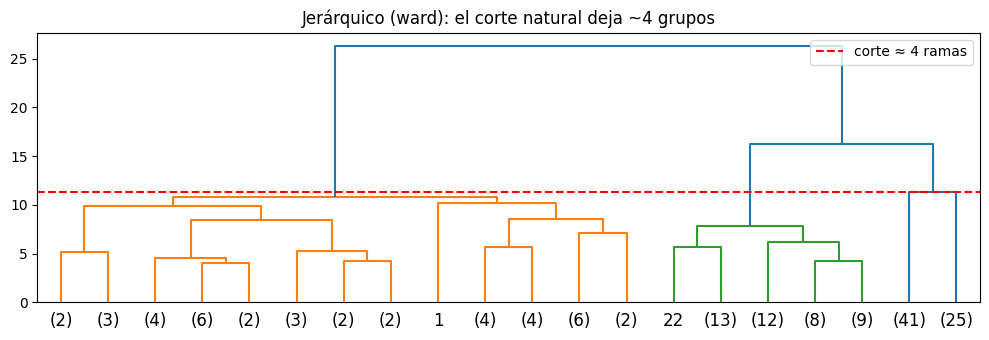

In [15]:
muestra=d.sample(min(150,len(d)),random_state=42).index
Z=linkage(X[d.index.isin(muestra)],method='ward')
plt.figure(figsize=(10,3.5))
dendrogram(Z,truncate_mode='lastp',p=20,color_threshold=Z[-3,2])
plt.axhline(Z[-3,2],color='red',ls='--',label='corte ≈ 4 ramas'); plt.title('Jerárquico (ward): el corte natural deja ~4 grupos')
plt.legend(); plt.tight_layout(); plt.show()

In [16]:
db=DBSCAN(eps=1.5,min_samples=10).fit(X)
d['dbscan']=np.where(db.labels_==-1,'ruido (atípicos)','núcleo denso')
fig=px.scatter(d,x='ingreso_estimado',y='gasto_total',color='dbscan',
    color_discrete_map={'núcleo denso':'#4C72B0','ruido (atípicos)':'#C44E52'},opacity=0.5,range_x=[0,4200000],
    title=f'DBSCAN: un núcleo denso + {int((db.labels_==-1).sum())} atípicos (= los heavy users)',labels={'ingreso_estimado':'ingreso','gasto_total':'gasto'})
fig.update_traces(marker=dict(size=5)); fijar(fig,440); fig.show()

## Qué se llevan

- El algoritmo corre en una línea; el laburo es bajar el problema a una pregunta, decidir qué es ruido y qué es señal, **elegir K con criterio** y convertir clusters en una **decisión**.
- La métrica acota; la decisión la firma el analista (silhouette decía k=2, el negocio dijo k=4).
- **Incrementalidad:** el cupón vale donde cambia la conducta (dormidos), no donde el pedido pasaba igual.

*La próxima: reducción de dimensionalidad — ¿y si tuviéramos 80 variables?*